In [ ]:
JAN_PATH = "jan2025_tripdata_sample_50k.csv.gz"
SEPT_PATH = "sept2025_tripdata_sample_50k.csv.gz"

Analysis of Citibike Rides Distance (Haversine) Jan 2025 vs September 2025

In [3]:
import pandas as pd

In [4]:
jan_rides = pd.read_csv("jan2025_tripdata_sample_75k.csv")
print(jan_rides.head())

            ride_id  rideable_type               started_at  \
0  DDB7F99E46E1D8DE  electric_bike  2025-01-02 08:24:41.527   
1  E09E05687EFDAD44   classic_bike  2025-01-15 10:59:49.416   
2  48FC24A9EFFA9C58   classic_bike  2025-01-02 14:14:01.748   
3  D65347EFDB676766   classic_bike  2025-01-12 08:36:08.626   
4  CEFB5F34AD41CBE4  electric_bike  2025-01-12 18:13:05.894   

                  ended_at            start_station_name start_station_id  \
0  2025-01-02 08:53:59.186                E 3 St & 1 Ave          5553.03   
1  2025-01-15 11:03:26.093  Prospect Ave & Vanderbilt St          3426.02   
2  2025-01-02 14:15:35.495               E 68 St & 3 Ave          6896.16   
3  2025-01-12 08:39:54.560              W 20 St & 10 Ave          6306.01   
4  2025-01-12 18:18:55.635          Henry St & Degraw St          4380.08   

               end_station_name end_station_id  start_lat  start_lng  \
0               7 Ave & W 55 St        6847.05  40.724677 -73.987834   
1  Prospect Av

In [5]:
sept_rides = pd.read_csv("sept2025_tripdata_sample_75k.csv")
print(sept_rides.head())

            ride_id  rideable_type               started_at  \
0  BAB8C3B98561898F   classic_bike  2025-09-08 19:47:33.411   
1  1A5CCCC145AEF3AA   classic_bike  2025-09-03 09:00:47.058   
2  86ABD18AB1EBDD27  electric_bike  2025-09-07 12:09:30.124   
3  BDAB8AA533EF550A   classic_bike  2025-09-14 10:59:11.781   
4  6C261C1636AB2FFC  electric_bike  2025-09-11 07:54:39.900   

                  ended_at   start_station_name start_station_id  \
0  2025-09-08 19:56:51.520     10 Ave & W 14 St          6157.04   
1  2025-09-03 09:04:33.649      E 17 St & 2 Ave          5896.01   
2  2025-09-07 12:13:20.167      W 21 St & 6 Ave          6140.05   
3  2025-09-14 11:01:36.857        44 Dr & 21 St          6319.03   
4  2025-09-11 08:11:32.989  Marcy Ave & Hart St          4593.05   

      end_station_name end_station_id  start_lat  start_lng    end_lat  \
0     W 33 St & 10 Ave        6492.04  40.741982 -74.008316  40.753773   
1   E 17 St & Broadway         5980.1  40.734312 -73.983725  40.

In [6]:
print(f"Number of rows in January DataFrame: {len(jan_rides)}")
jan_rides.dropna(inplace=True)
print(f"Number of rows in September DataFrame: {len(sept_rides)}")
sept_rides.dropna(inplace=True)

print("\nAfter dropping missing values:")

print("January values:" , len(jan_rides))
print("September values:" , len(sept_rides))

Number of rows in January DataFrame: 75000
Number of rows in September DataFrame: 75000

After dropping missing values:
January values: 74810
September values: 74770


Crunching the Numbers

In [7]:
import numpy as np

In [8]:
jan_rides['change_lat'] = jan_rides['end_lat'] - jan_rides['start_lat']
jan_rides['change_lng'] = jan_rides['end_lng'] - jan_rides['start_lng']
jan_rides['change_lng'] = np.deg2rad(jan_rides['change_lng'])
jan_rides['change_lat'] = np.deg2rad(jan_rides['change_lat'])
print(jan_rides[['change_lat', 'change_lng']].head())

sept_rides['change_lat'] = sept_rides['end_lat'] - sept_rides['start_lat']
sept_rides['change_lng'] = sept_rides['end_lng'] - sept_rides['start_lng']  
sept_rides['change_lng'] = np.deg2rad(sept_rides['change_lng'])
sept_rides['change_lat'] = np.deg2rad(sept_rides['change_lat'])
print(sept_rides[['change_lat', 'change_lng']].head())

   change_lat  change_lng
0    0.000689    0.000120
1   -0.000028    0.000005
2   -0.000037    0.000071
3   -0.000058    0.000138
4    0.000036    0.000340
   change_lat  change_lng
0    0.000206    0.000156
1    0.000047   -0.000112
2   -0.000029   -0.000194
3   -0.000039   -0.000071
4    0.000480   -0.000180


In [9]:
jan_rides['a'] = np.power(np.sin(jan_rides['change_lat'] / 2) , 2) +  np.cos(np.deg2rad(jan_rides['start_lat'])) * np.cos(np.deg2rad(jan_rides['end_lat'])) * np.power(np.sin(jan_rides['change_lng'] / 2), 2)
sept_rides['a'] = np.power(np.sin(sept_rides['change_lat'] / 2) , 2) +  np.cos(np.deg2rad(sept_rides['start_lat'])) * np.cos(np.deg2rad(sept_rides['end_lat'])) * np.power(np.sin(sept_rides['change_lng'] / 2), 2)

jan_rides['c'] = 2 * np.arctan2(np.sqrt(jan_rides['a']), np.sqrt(1 - jan_rides['a']))
sept_rides['c'] = 2 * np.arctan2(np.sqrt(sept_rides['a']), np.sqrt(1 - sept_rides['a']))

R = 3959  # Radius of the Earth in miles
jan_rides['haversine_distance_miles'] = R * jan_rides['c']
sept_rides['haversine_distance_miles'] = R * sept_rides['c']

In [10]:
print("January distances (miles):" , jan_rides['haversine_distance_miles'].describe())
print("September distances (miles):" , sept_rides['haversine_distance_miles'].describe())

January distances (miles): count    74810.000000
mean         1.065833
std          0.896327
min          0.000000
25%          0.486768
50%          0.807684
75%          1.352528
max         11.045317
Name: haversine_distance_miles, dtype: float64
September distances (miles): count    74770.000000
mean         1.310917
std          1.106093
min          0.000000
25%          0.556673
50%          0.984730
75%          1.725313
max         12.087346
Name: haversine_distance_miles, dtype: float64


In [11]:
jan_rides = jan_rides[jan_rides['haversine_distance_miles'] != 0].copy()
sept_rides = sept_rides[sept_rides['haversine_distance_miles'] != 0].copy()

print("January distances (miles):" , jan_rides['haversine_distance_miles'].describe())
print("September distances (miles):" , sept_rides['haversine_distance_miles'].describe())

January distances (miles): count    73761.000000
mean         1.080991
std          0.893556
min          0.024943
25%          0.498415
50%          0.818514
75%          1.363402
max         11.045317
Name: haversine_distance_miles, dtype: float64
September distances (miles): count    73271.000000
mean         1.337736
std          1.101178
min          0.024830
25%          0.580329
50%          1.006001
75%          1.746467
max         12.087346
Name: haversine_distance_miles, dtype: float64


Ploting Data

In [12]:
import matplotlib.pyplot as plt

C:\Users\pokek\AppData\Local\Temp\ipykernel_21180\1601217953.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([jan_rides["haversine_distance_miles"], sept_rides["haversine_distance_miles"]],


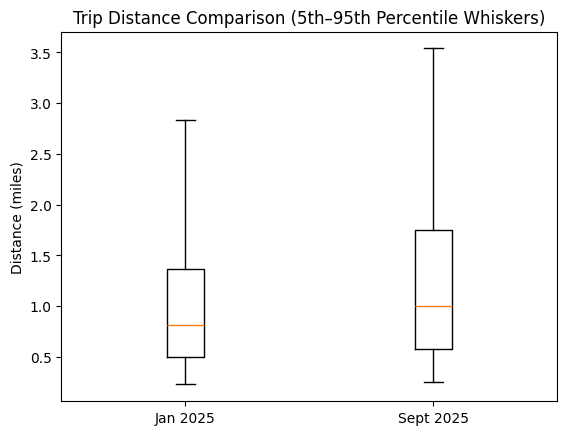

In [13]:
plt.figure()
plt.boxplot([jan_rides["haversine_distance_miles"], sept_rides["haversine_distance_miles"]],
            labels=["Jan 2025", "Sept 2025"], showfliers=False, whis=(5,95))
plt.title("Trip Distance Comparison (5th–95th Percentile Whiskers)")
plt.ylabel("Distance (miles)")
plt.show()

In [14]:
jan_total = jan_rides["haversine_distance_miles"].sum()
sept_total = sept_rides["haversine_distance_miles"].sum()

print("Jan total miles:", jan_total)
print("Sept total miles:", sept_total)

print("Jan miles per 10k rides:", jan_total / len(jan_rides) * 10_000)
print("Sept miles per 10k rides:", sept_total / len(sept_rides) * 10_000)

Jan total miles: 79734.96576858524
Sept total miles: 98017.24726235775
Jan miles per 10k rides: 10809.908456851894
Sept miles per 10k rides: 13377.359018214265


In [15]:
print(jan_rides[jan_rides['member_casual'] == 'casual']['haversine_distance_miles'].describe())

print(sept_rides[sept_rides['member_casual'] == 'casual']['haversine_distance_miles'].describe())

count    6779.000000
mean        1.201395
std         0.924035
min         0.033159
25%         0.606351
50%         0.934688
75%         1.475849
max        11.045317
Name: haversine_distance_miles, dtype: float64
count    13725.000000
mean         1.468232
std          1.090725
min          0.041223
25%          0.712574
50%          1.160601
75%          1.902676
max         10.755897
Name: haversine_distance_miles, dtype: float64


In [16]:
jan_rides.groupby("member_casual")["haversine_distance_miles"].describe()
sept_rides.groupby("member_casual")["haversine_distance_miles"].describe()

print(jan_rides["member_casual"].value_counts(normalize=True))
print(sept_rides["member_casual"].value_counts(normalize=True))

member_casual
member    0.908095
casual    0.091905
Name: proportion, dtype: float64
member_casual
member    0.812682
casual    0.187318
Name: proportion, dtype: float64


In [18]:
pJ = jan_rides["member_casual"].value_counts(normalize=True)["casual"]
pS = sept_rides["member_casual"].value_counts(normalize=True)["casual"]

muJ_c = jan_rides.loc[jan_rides["member_casual"]=="casual", "haversine_distance_miles"].mean()
muJ_m = jan_rides.loc[jan_rides["member_casual"]=="member", "haversine_distance_miles"].mean()

muS_c = sept_rides.loc[sept_rides["member_casual"]=="casual", "haversine_distance_miles"].mean()
muS_m = sept_rides.loc[sept_rides["member_casual"]=="member", "haversine_distance_miles"].mean()

muJ = pJ*muJ_c + (1-pJ)*muJ_m
muS = pS*muS_c + (1-pS)*muS_m

# Mix shift only (use Jan means, Sept proportions)
mix_only = pS*muJ_c + (1-pS)*muJ_m

composition_effect = mix_only - muJ
within_group_effect = muS - mix_only

print("Overall mean Jan:", muJ)
print("Overall mean Sept:", muS)
print("Total increase:", muS - muJ)

print("Composition (more casual):", composition_effect)
print("Within-group (rides longer):", within_group_effect)


Overall mean Jan: 1.080990845685189
Overall mean Sept: 1.3377359018214268
Total increase: 0.25674505613623766
Composition (more casual): 0.01265079616559217
Within-group (rides longer): 0.2440942599706455


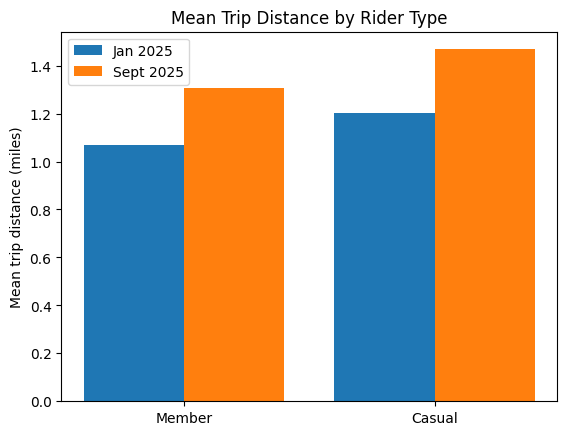

In [19]:
labels = ["Member", "Casual"]
jan_means = [muJ_m, muJ_c]
sept_means = [muS_m, muS_c]

x = range(len(labels))

plt.figure()
plt.bar([i-0.2 for i in x], jan_means, width=0.4, label="Jan 2025")
plt.bar([i+0.2 for i in x], sept_means, width=0.4, label="Sept 2025")
plt.xticks(list(x), labels)
plt.ylabel("Mean trip distance (miles)")
plt.title("Mean Trip Distance by Rider Type")
plt.legend()
plt.show()